In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy import NaN
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier

In [2]:
col = ["duration","protocol_type","service","flag","src-bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num-compromised","root-shell","su-attempted","num_root","num_file_creation","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_error_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","class_attack","class_score"]
url = "KDDTest+1.csv"
data = pd.read_csv(url,names=col)
data.shape

(22544, 43)

In [3]:
# remove attribute 'difficulty_level'
data.drop(['class_score'],axis=1,inplace=True)
data.shape

(22544, 42)

In [4]:
# discriptive statistics of the dataset
data.describe()

,duration,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num-compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,193.869411,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,94.035663,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.000000,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
data.head(10)

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class_attack
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,saint
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,mscan
5,0,tcp,http,SF,267,14515,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.01,0.00,0.00,0.00,normal
6,0,tcp,smtp,SF,1022,387,0,0,0,0,...,28,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal
7,0,tcp,telnet,SF,129,174,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.01,0.01,0.02,0.02,guess_passwd
8,0,tcp,http,SF,327,467,0,0,0,0,...,255,1.00,0.00,0.01,0.03,0.00,0.00,0.00,0.00,normal
9,0,tcp,ftp,SF,26,157,0,0,0,0,...,26,0.50,0.08,0.02,0.00,0.00,0.00,0.00,0.00,guess_passwd


In [6]:
# number of attack labels 
data['class_attack'].value_counts()


normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
rootkit              13
xterm                13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
worm                  2
loadmodule            2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: class_attack, dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src-bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num-compromised              22544 non-null  int64  
 13  root-shell      

In [10]:
# changing attack labels to their respective attack class
# total 38 different sub-attacks 
def change_label(df):
  df.class_attack.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],'Dos',inplace=True)
  df.class_attack.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail',
       'snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],'R2L',inplace=True)
  df.class_attack.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],'Probe',inplace=True)
  df.class_attack.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],'U2R',inplace=True)


In [11]:
# calling change_label() function
change_label(data)

In [12]:
# distribution of attack classes
data.class_attack.value_counts()

normal    9711
Dos       7460
R2L       2885
Probe     2421
U2R         67
Name: class_attack, dtype: int64

In [13]:
#### data normalization #####

In [14]:
# importing required libraries for normalizing data
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

In [15]:
# selecting numeric attributes columns from data
numeric_col = data.select_dtypes(include='number').columns

# using standard scaler for normalizing
std_scaler = StandardScaler()
def normalization(df,col):
  for i in col:
    arr = df[i]
    arr = np.array(arr)
    df[i] = std_scaler.fit_transform(arr.reshape(len(arr),1))
  return df


In [16]:
# data before normalization
data.head()

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class_attack
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,Dos
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,Dos
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,Probe
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,Probe


In [17]:
# calling the normalization() function
data = normalization(data.copy(),numeric_col)

# data after normalization
data.head()

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class_attack
0,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-1.169697,-1.305370,-0.138370,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,Dos
1,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-1.250212,-1.397181,-0.138370,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,Dos
2,-0.154113,tcp,ftp_data,SF,0.005473,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.489800,0.002934,-0.228985,1.559906,0.004234,-0.358118,-0.35275,-0.602719,-0.565483,normal
3,-0.155534,icmp,eco_i,SF,-0.021946,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.749234,0.898090,-0.410217,2.833328,3.049016,-0.358118,-0.35275,-0.602719,-0.565483,Probe
4,-0.154823,tcp,telnet,RSTO,-0.021988,-0.096189,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.489800,-0.685647,0.360018,-0.333901,0.004234,-0.358118,-0.35275,1.540764,1.205682,Probe


In [18]:
#### one hot encoding ####

In [19]:
# selecting categorical data attributes
cat_col = ['protocol_type','service','flag']

# creating a dataframe with only categorical attributes
categorical = data[cat_col]
categorical.head()

,protocol_type,service,flag
0,tcp,private,REJ
1,tcp,private,REJ
2,tcp,ftp_data,SF
3,icmp,eco_i,SF
4,tcp,telnet,RSTO


In [20]:
# one-hot-encoding categorical attributes using pandas.get_dummies() function
categorical = pd.get_dummies(categorical,columns=cat_col)
categorical.head()

,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_auth,service_bgp,service_courier,service_csnet_ns,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [21]:
#### binary classification ######

In [22]:
# changing attack labels into two categories 'normal' and 'abnormal'
bin_label = pd.DataFrame(data.class_attack.map(lambda x:'normal' if x=='normal' else 'abnormal'))

In [23]:
# creating a dataframe with binary labels (normal,abnormal)
bin_data_test = data.copy()
bin_data_test['class_attack'] = bin_label

In [24]:
# label encoding (0,1) binary labels (abnormal,normal)
le1_test = preprocessing.LabelEncoder()
enc_label = bin_label.apply(le1_test.fit_transform)
bin_data_test['intrusion'] = enc_label

In [25]:
le1_test.classes_

array(['abnormal', 'normal'], dtype=object)

In [26]:
np.save("le1_classes_test.npy",le1_test.classes_,allow_pickle=True)

In [27]:
# dataset with binary labels and label encoded column
bin_data_test.head()

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class_attack,intrusion
0,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-1.305370,-0.138370,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,abnormal,0
1,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-1.397181,-0.138370,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,abnormal,0
2,-0.154113,tcp,ftp_data,SF,0.005473,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,0.002934,-0.228985,1.559906,0.004234,-0.358118,-0.35275,-0.602719,-0.565483,normal,1
3,-0.155534,icmp,eco_i,SF,-0.021946,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,0.898090,-0.410217,2.833328,3.049016,-0.358118,-0.35275,-0.602719,-0.565483,abnormal,0
4,-0.154823,tcp,telnet,RSTO,-0.021988,-0.096189,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.685647,0.360018,-0.333901,0.004234,-0.358118,-0.35275,1.540764,1.205682,abnormal,0


In [28]:
# one-hot-encoding attack label
bin_data_test = pd.get_dummies(bin_data_test,columns=['class_attack'],prefix="",prefix_sep="") 
bin_data_test['class_attack'] = bin_label
bin_data_test

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion,abnormal,normal,class_attack
0,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,0,1,0,abnormal
1,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.431856,-0.229980,-0.358118,-0.35275,1.979791,1.929116,0,1,0,abnormal
2,-0.154113,tcp,ftp_data,SF,0.005473,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,1.559906,0.004234,-0.358118,-0.35275,-0.602719,-0.565483,1,0,1,normal
3,-0.155534,icmp,eco_i,SF,-0.021946,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,2.833328,3.049016,-0.358118,-0.35275,-0.602719,-0.565483,0,1,0,abnormal
4,-0.154823,tcp,telnet,RSTO,-0.021988,-0.096189,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.333901,0.004234,-0.358118,-0.35275,1.540764,1.205682,0,1,0,abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,-0.155534,tcp,smtp,SF,-0.020309,-0.081202,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.399204,-0.112873,-0.321505,-0.35275,-0.602719,-0.565483,1,0,1,normal
22540,-0.155534,tcp,http,SF,-0.021318,-0.052690,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.399204,-0.112873,-0.321505,-0.35275,-0.602719,-0.565483,1,0,1,normal
22541,-0.155534,tcp,http,SF,0.093373,0.294926,-0.017624,-0.059104,-0.019459,2.040705,...,-0.431856,-0.229980,-0.358118,-0.35275,-0.421943,-0.390861,0,1,0,abnormal
22542,-0.155534,udp,domain_u,SF,-0.021899,-0.094917,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.431856,-0.229980,-0.358118,-0.35275,-0.602719,-0.565483,1,0,1,normal


In [29]:
bin_data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  float64
 1   protocol_type                22544 non-null  object 
 2   service                      22544 non-null  object 
 3   flag                         22544 non-null  object 
 4   src-bytes                    22544 non-null  float64
 5   dst_bytes                    22544 non-null  float64
 6   land                         22544 non-null  float64
 7   wrong_fragment               22544 non-null  float64
 8   urgent                       22544 non-null  float64
 9   hot                          22544 non-null  float64
 10  num_failed_logins            22544 non-null  float64
 11  logged_in                    22544 non-null  float64
 12  num-compromised              22544 non-null  float64
 13  root-shell      

In [26]:
# importing library for plotting
import matplotlib.pyplot as plt

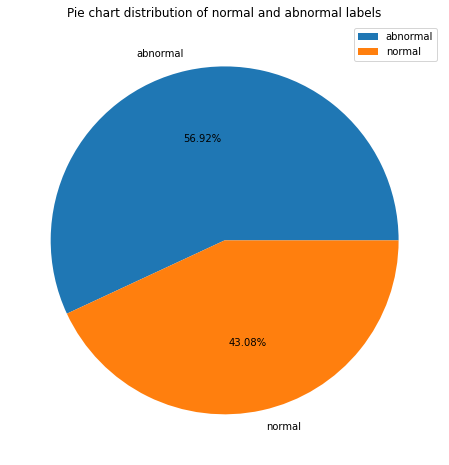

In [27]:
# pie chart distribution of normal and abnormal labels
plt.figure(figsize=(8,8))
plt.pie(bin_data_test.class_attack.value_counts(),labels=bin_data_test.class_attack.unique(),autopct='%0.2f%%')
plt.title("Pie chart distribution of normal and abnormal labels")
plt.legend()
plt.show()


In [28]:
### multiclass classification #####

In [29]:
# creating a dataframe with multi-class labels (Dos,Probe,R2L,U2R,normal)
multi_data_test = data.copy()
multi_label_test = pd.DataFrame(multi_data_test.class_attack)

In [30]:
# label encoding (0,1,2,3,4) multi-class labels (Dos,normal,Probe,R2L,U2R)
le2_test = preprocessing.LabelEncoder()
enc_label = multi_label_test.apply(le2_test.fit_transform)
multi_data_test['intrusion'] = enc_label

In [31]:
le2_test.classes_

array(['Dos', 'Probe', 'R2L', 'U2R', 'normal'], dtype=object)

In [32]:
np.save("le2_classes_test.npy",le2_test.classes_,allow_pickle=True)

In [33]:
# one-hot-encoding attack label
multi_data_test = pd.get_dummies(multi_data_test,columns=['class_attack'],prefix="",prefix_sep="") 
multi_data_test['class_attack'] = multi_label_test
multi_data_test

,duration,protocol_type,service,flag,src-bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,intrusion,Dos,Probe,R2L,U2R,normal,class_attack
0,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,1.979791,1.929116,0,1,0,0,0,0,Dos
1,-0.155534,tcp,private,REJ,-0.021988,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,1.979791,1.929116,0,1,0,0,0,0,Dos
2,-0.154113,tcp,ftp_data,SF,0.005473,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,-0.602719,-0.565483,4,0,0,0,0,1,normal
3,-0.155534,icmp,eco_i,SF,-0.021946,-0.096896,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,-0.602719,-0.565483,1,0,1,0,0,0,Probe
4,-0.154823,tcp,telnet,RSTO,-0.021988,-0.096189,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,1.540764,1.205682,1,0,1,0,0,0,Probe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,-0.155534,tcp,smtp,SF,-0.020309,-0.081202,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,-0.602719,-0.565483,4,0,0,0,0,1,normal
22540,-0.155534,tcp,http,SF,-0.021318,-0.052690,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,-0.602719,-0.565483,4,0,0,0,0,1,normal
22541,-0.155534,tcp,http,SF,0.093373,0.294926,-0.017624,-0.059104,-0.019459,2.040705,...,-0.35275,-0.421943,-0.390861,0,1,0,0,0,0,Dos
22542,-0.155534,udp,domain_u,SF,-0.021899,-0.094917,-0.017624,-0.059104,-0.019459,-0.113521,...,-0.35275,-0.602719,-0.565483,4,0,0,0,0,1,normal


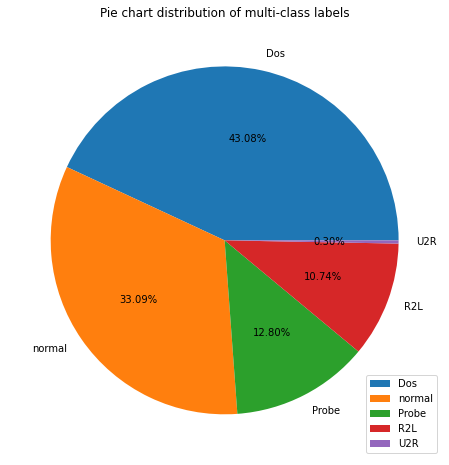

In [34]:
# pie chart distribution of multi-class labels
plt.figure(figsize=(8,8))
plt.pie(multi_data_test.class_attack.value_counts(),labels=multi_data_test.class_attack.unique(),autopct='%0.2f%%')
plt.title('Pie chart distribution of multi-class labels')
plt.legend()
plt.show()

In [35]:
#### feature extraction ####

In [36]:
# creating a dataframe with only numeric attributes of binary class dataset and encoded label attribute 
numeric_bin = bin_data_test[numeric_col]
numeric_bin['intrusion'] = bin_data_test['intrusion']

/tmp/ipykernel_620859/1758268502.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_bin['intrusion'] = bin_data_test['intrusion']


In [37]:
# finding the attributes which have more than 0.5 correlation with encoded attack label attribute 
corr= numeric_bin.corr()
corr_y = abs(corr['intrusion'])
highest_corr = corr_y[corr_y >0.5]
highest_corr.sort_values(ascending=True)

same_srv_rate             0.510634
logged_in                 0.551159
dst_host_same_srv_rate    0.575526
dst_host_srv_count        0.593344
intrusion                 1.000000
Name: intrusion, dtype: float64

In [38]:
# selecting attributes found by using pearson correlation coefficient
numeric_bin = bin_data_test[['logged_in','dst_host_same_srv_rate','dst_host_srv_count','same_srv_rate']]

In [39]:
# joining the selected attribute with the one-hot-encoded categorical dataframe
numeric_bin = numeric_bin.join(categorical)
# then joining encoded, one-hot-encoded, and original attack label attribute
bin_data_test = numeric_bin.join(bin_data_test[['intrusion','abnormal','normal','class_attack']])

In [40]:
# saving final dataset to disk
#bin_data_test.to_csv("datasets/bin_data_test.csv")
# final dataset for binary classification
bin_data_test

,logged_in,dst_host_same_srv_rate,dst_host_srv_count,same_srv_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,...,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,intrusion,abnormal,normal,class_attack
0,-0.890373,-1.305370,-1.169697,-1.697859,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,abnormal
1,-0.890373,-1.397181,-1.250212,-1.770589,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,abnormal
2,-0.890373,0.002934,-0.489800,0.629488,0,1,0,0,0,0,...,0,0,0,0,1,0,1,0,1,normal
3,-0.890373,0.898090,-0.749234,0.629488,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,abnormal
4,-0.890373,-0.685647,-0.489800,0.629488,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,1.123125,0.255414,0.002232,0.629488,0,1,0,0,0,0,...,0,0,0,0,1,0,1,0,1,normal
22540,1.123125,0.898090,1.022079,0.629488,0,1,0,0,0,0,...,0,0,0,0,1,0,1,0,1,normal
22541,1.123125,0.898090,1.022079,0.629488,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,abnormal
22542,-0.890373,0.875137,0.995240,0.629488,0,0,1,0,0,0,...,0,0,0,0,1,0,1,0,1,normal


In [41]:
# creating a dataframe with only numeric attributes of multi-class dataset and encoded label attribute 
numeric_multi = multi_data_test[numeric_col]
numeric_multi['intrusion'] = multi_data_test['intrusion']

/tmp/ipykernel_620859/3380547693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_multi['intrusion'] = multi_data_test['intrusion']


In [42]:
# finding the attributes which have more than 0.5 correlation with encoded attack label attribute 
corr = numeric_multi.corr()
corr_y = abs(corr['intrusion'])
highest_corr = corr_y[corr_y >0.5]
highest_corr.sort_values(ascending=True)

dst_host_srv_rerror_rate    0.540813
srv_error_rate              0.547787
rerror_rate                 0.553599
dst_host_rerror_rate        0.570808
logged_in                   0.572717
dst_host_srv_count          0.575061
dst_host_same_srv_rate      0.605472
same_srv_rate               0.614762
intrusion                   1.000000
Name: intrusion, dtype: float64

In [43]:
# selecting attributes found by using pearson correlation coefficient
numeric_multi = multi_data_test[['logged_in','srv_serror_rate','rerror_rate','dst_host_rerror_rate',
                        'dst_host_same_srv_rate','dst_host_srv_serror_rate','dst_host_srv_count','same_srv_rate']]

# joining the selected attribute with the one-hot-encoded categorical dataframe
numeric_multi = numeric_multi.join(categorical)
# then joining encoded, one-hot-encoded, and original attack label attribute
multi_data_test = numeric_multi.join(multi_data_test[['intrusion','Dos','Probe','R2L','U2R','normal','class_attack']])

In [44]:
# saving final dataset to disk
#multi_data_test.to_csv('datasets/multi_data_test.csv')

# final dataset for multi-class classification
multi_data_test

,logged_in,srv_serror_rate,rerror_rate,dst_host_rerror_rate,dst_host_same_srv_rate,dst_host_srv_serror_rate,dst_host_srv_count,same_srv_rate,protocol_type_icmp,protocol_type_tcp,...,flag_S3,flag_SF,flag_SH,intrusion,Dos,Probe,R2L,U2R,normal,class_attack
0,-0.890373,-0.347390,1.830141,1.979791,-1.305370,-0.35275,-1.169697,-1.697859,0,1,...,0,0,0,0,1,0,0,0,0,Dos
1,-0.890373,-0.347390,1.830141,1.979791,-1.397181,-0.35275,-1.250212,-1.770589,0,1,...,0,0,0,0,1,0,0,0,0,Dos
2,-0.890373,-0.347390,-0.573079,-0.602719,0.002934,-0.35275,-0.489800,0.629488,0,1,...,0,1,0,4,0,0,0,0,1,normal
3,-0.890373,-0.347390,-0.573079,-0.602719,0.898090,-0.35275,-0.749234,0.629488,1,0,...,0,1,0,1,0,1,0,0,0,Probe
4,-0.890373,0.054856,1.830141,1.540764,-0.685647,-0.35275,-0.489800,0.629488,0,1,...,0,0,0,1,0,1,0,0,0,Probe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,1.123125,-0.347390,-0.573079,-0.602719,0.255414,-0.35275,0.002232,0.629488,0,1,...,0,1,0,4,0,0,0,0,1,normal
22540,1.123125,-0.347390,-0.573079,-0.602719,0.898090,-0.35275,1.022079,0.629488,0,1,...,0,1,0,4,0,0,0,0,1,normal
22541,1.123125,-0.347390,-0.573079,-0.421943,0.898090,-0.35275,1.022079,0.629488,0,1,...,0,1,0,0,1,0,0,0,0,Dos
22542,-0.890373,-0.347390,-0.573079,-0.602719,0.875137,-0.35275,0.995240,0.629488,0,0,...,0,1,0,4,0,0,0,0,1,normal


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import svm
from sklearn.ensemble import ExtraTreesClassifier
import time
import warnings
from sklearn.metrics import roc_curve,auc

In [46]:
# classifier for binary classification dataset

warnings.filterwarnings("ignore")

X = bin_data_test.iloc[:,0:82].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = bin_data_test['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC(gamma='auto')))

print ('Model\tAcc\tpr\tRecall\tF1\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    precision = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='precision').mean()
    recall = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='recall').mean()
    f1score = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='f1_weighted').mean()
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    
    delta = time.time()- start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, precision, recall, f1score, false_alaram_rate, sensitivity, specificity, delta))
    print(cm_df)
    
    

Model	Acc	pr	Recall	F1	FAR	sen	spe	Execution_time
LR	0.924	0.885	0.947	0.925	0.045	0.875	0.955	3.06 sec
      0     1
0  2300   262
1   108  1839
LDA	0.925	0.886	0.947	0.925	0.047	0.877	0.953	10.34 sec
      0     1
0  2304   258
1   113  1834
KNN	0.949	0.934	0.949	0.949	0.046	0.928	0.954	22.96 sec
      0     1
0  2420   142
1   116  1831
CART	0.945	0.932	0.941	0.945	0.047	0.927	0.953	2.53 sec
      0     1
0  2417   145
1   119  1828
SVM	0.920	0.884	0.937	0.920	0.047	0.875	0.953	348.74 sec
      0     1
0  2301   261
1   113  1834


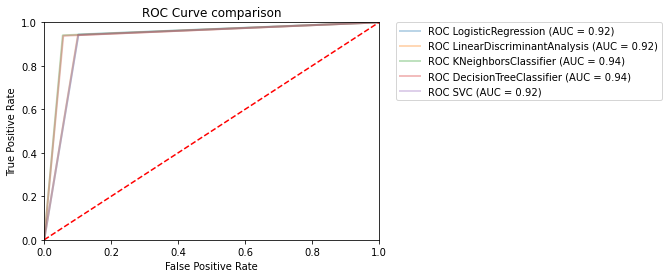

In [47]:
# Creating plot to show the ROC for all MLA
index = 1
for name, model in models:
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    fp, tp, th = roc_curve(Y_validation, predict)
    roc_auc_mla = auc(fp, tp)
    MLA_name = model.__class__.__name__
    plt.plot(fp, tp, lw=2, alpha=0.3, label='ROC %s (AUC = %0.2f)'  % (MLA_name, roc_auc_mla))
index+=1

plt.title('ROC Curve comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')    
plt.show()

In [48]:
# classifier for multi-classification dataset


X = multi_data_test.iloc[:,0:82].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data_test['intrusion'] # target attribute

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('SVM', SVC(gamma='auto')))

print ('Model\tAcc\tFAR\tsen\tspe\tExecution_time')

# evaluate each model in turn
results = []
names = []

for name, model in models:
    start_time = time.time()
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy').mean()
    
    
    m = model.fit(X_train, Y_train)
    predict = m.predict(X_validation)
    cm = confusion_matrix(Y_validation, predict)
    # Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
    cm_df = pd.DataFrame(cm)
    
    total1=sum(sum(cm))
    false_alaram_rate = cm[1,0]/(cm[1,0]+cm[0,0])
    sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
    specificity = cm[0,0]/(cm[1,0]+cm[0,0])
    f1score = precision_recall_fscore_support(Y_validation, predict,average='weighted')
    
    delta = time.time()- start_time
    results.append(cv_results)
    names.append(name)
    print('{}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.2f} sec'.format(name, cv_results, false_alaram_rate, sensitivity, specificity, delta))
    print(f1score)
    print(cm_df)

Model	Acc	FAR	sen	spe	Execution_time
LR	0.898	0.072	0.964	0.928	4.92 sec
(0.8859766979201695, 0.8862275449101796, 0.8837684123034989, None)
      0    1    2  3     4
0  1383   12   12  2   113
1   107  324    6  0    31
2     0    8  434  0   120
3     1    0    5  3     1
4    34   29   32  0  1852
LDA	0.878	0.084	0.921	0.916	3.50 sec
(0.8691577836129896, 0.8687070303836771, 0.8671534978914199, None)
      0    1    2  3     4
0  1352   26   12  2   130
1   124  303    2  4    35
2     0   14  446  2   100
3     0    0    4  6     0
4    29   20   81  7  1810
KNN	0.955	0.007	0.978	0.993	7.56 sec
(0.9416685139231136, 0.9339099578620537, 0.9356689870622379, None)
      0    1    2  3     4
0  1497   10    0  0    15
1    11  445    1  0    11
2     2    4  528  2    26
3     0    0    4  4     2
4    20    7  176  7  1737
CART	0.958	0.005	0.996	0.995	0.75 sec
(0.959063032670912, 0.957418496340652, 0.9581699171034654, None)
      0    1    2  3     4
0  1507    2    1  0    12
1     7  

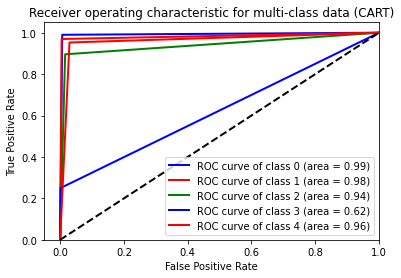

In [49]:
# roc auc plot for multiclass
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

X = multi_data_test.iloc[:,0:82].to_numpy() # dataset excluding target attribute (encoded, one-hot-encoded,original)
y = multi_data_test['intrusion'] # target attribute

# Binarize the output
y = label_binarize(y, classes=[0, 1, 2,3,4])
n_classes = y.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5, random_state=0)

#classifier = OneVsRestClassifier(svm.SVC(kernel='linear', probability=True,random_state=0))

classifier = OneVsRestClassifier(DecisionTreeClassifier())

y_score = classifier.fit(X_train, y_train)
ypred = y_score.predict(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], ypred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for multi-class data (CART)')
plt.legend(loc="lower right")
plt.show()